<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/khushalha/notebooks/cicids_multi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Load the dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (692703, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12                         3452   
4                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   
3                   

In [ ]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
692698,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692699,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692700,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692701,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692702,53,94939,4,2,188,226,47,47,47.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


3. Information about CICIDS2017 dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-nul

4. Statistical description of dataset

In [ ]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,692703.000000,6.927030e+05,692703.000000,692703.000000,6.927030e+05,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,...,692703.000000,692703.000000,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05
mean,5686.869462,2.800168e+07,9.556261,10.214079,5.550930e+02,1.699644e+04,233.593936,15.022183,60.555440,82.895863,...,6.121279,26.761141,9.224478e+04,4.760852e+04,1.627363e+05,6.315186e+04,2.211122e+07,4.743744e+05,2.252174e+07,2.173373e+07
std,15727.423560,4.276680e+07,747.197814,984.204633,6.163663e+03,2.241175e+06,603.751856,51.068835,157.643794,226.126084,...,715.155068,6.322368,7.007049e+05,4.742081e+05,1.094616e+06,6.051023e+05,3.812415e+07,4.488512e+06,3.848292e+07,3.807725e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,2.010000e+02,2.000000,1.000000,1.200000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.143700e+04,2.000000,2.000000,8.200000e+01,1.880000e+02,46.000000,0.000000,41.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,8.302437e+07,7.000000,6.000000,3.650000e+02,1.159500e+04,341.000000,32.000000,56.666667,128.916917,...,2.000000,32.000000,9.910000e+02,0.000000e+00,9.910000e+02,9.880000e+02,1.590000e+07,0.000000e+00,1.650000e+07,1.000000e+07
max,65487.000000,1.200000e+08,203943.000000,272353.000000,1.224076e+06,6.270000e+08,24820.000000,2065.000000,4640.757576,6429.190773,...,197124.000000,60.000000,1.000000e+08,7.420000e+07,1.050000e+08,1.000000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


5. Check for missing values

In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 1008


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


6. Remove unecessary columns

In [ ]:
df.columns = df.columns.str.strip()
drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [ ]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,38308,1,1,6,6,6,6,6.000000,0.000000,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,479,11,5,172,326,79,0,15.636364,31.449238,163,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,1095,10,6,3150,3150,1575,0,315.000000,632.561635,1575,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,15206,17,12,3452,6660,1313,0,203.058823,425.778474,3069,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1092,9,6,3150,3152,1575,0,350.000000,694.509719,1576,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


7. Remove the duplicates

In [ ]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (691406, 78)
After removing duplicates: (584991, 78)


8. Types of attacks in CICIDS2017

/tmp/ipython-input-4068402929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_attacks, order=df_attacks.value_counts().index, palette="magma")


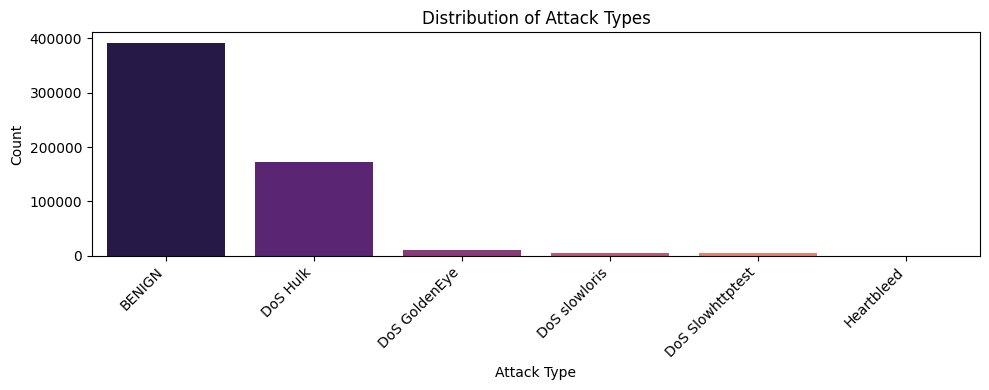

In [ ]:
df_attacks = df['Label']
plt.figure(figsize=(10, 4))
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index, palette="magma")
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

9. Applying Label Encoding

In [ ]:
def le(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      label_encoder=LabelEncoder()
      df[col]=label_encoder.fit_transform(df[col])
le(df)

In [ ]:
print(f"Shape of training data after encoding: {df.shape}")

Shape of training data after encoding: (584991, 78)


In [ ]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,38308,1,1,6,6,6,6,6.000000,0.000000,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,479,11,5,172,326,79,0,15.636364,31.449238,163,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,1095,10,6,3150,3150,1575,0,315.000000,632.561635,1575,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
3,15206,17,12,3452,6660,1313,0,203.058823,425.778474,3069,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
4,1092,9,6,3150,3152,1575,0,350.000000,694.509719,1576,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0


10. Correlation map

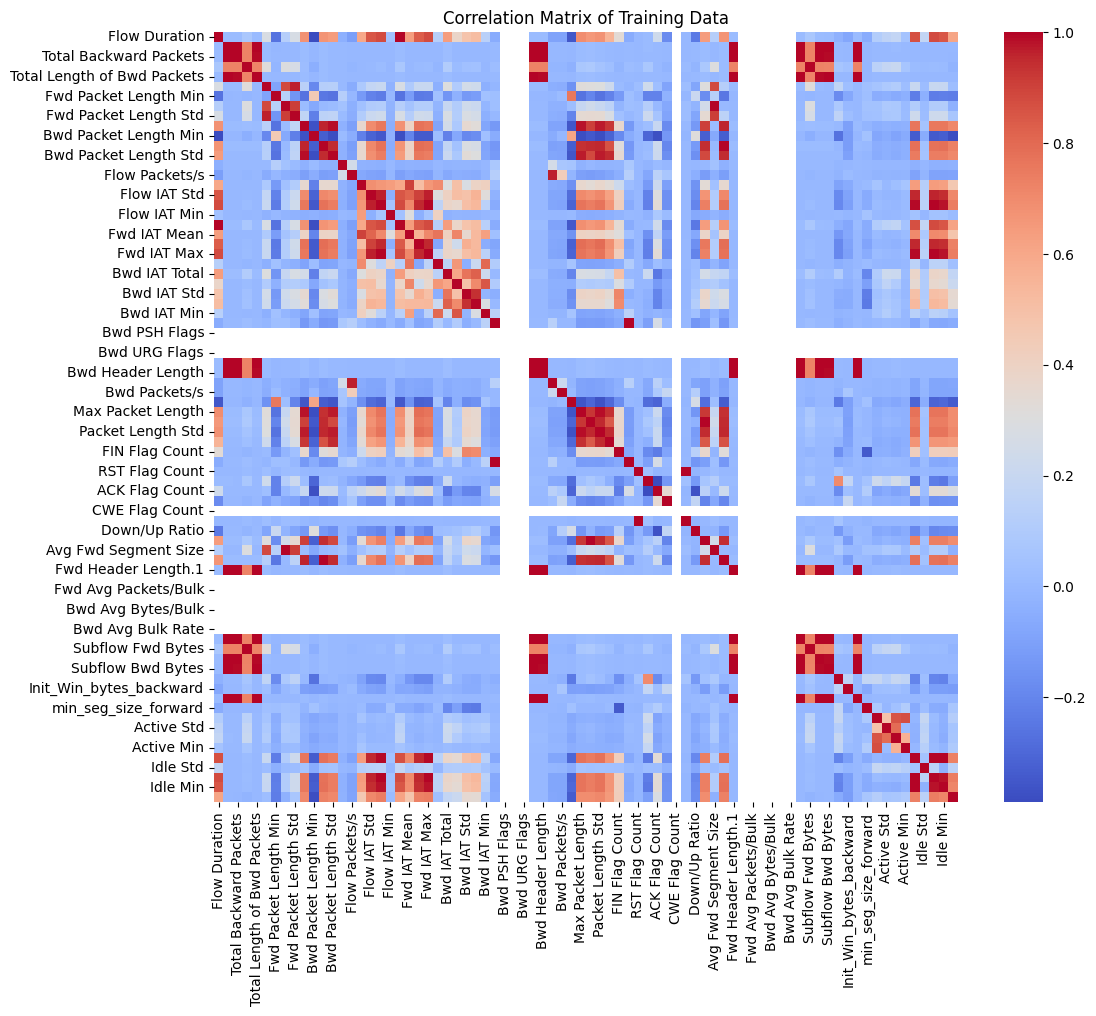

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Training Data')
plt.show()

11. Assigning labels

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [ ]:
X.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,38308,1,1,6,6,6,6,6.000000,0.000000,6,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
1,479,11,5,172,326,79,0,15.636364,31.449238,163,...,4,32,0.0,0.0,0,0,0.0,0.0,0,0
2,1095,10,6,3150,3150,1575,0,315.000000,632.561635,1575,...,3,32,0.0,0.0,0,0,0.0,0.0,0,0
3,15206,17,12,3452,6660,1313,0,203.058823,425.778474,3069,...,10,32,0.0,0.0,0,0,0.0,0.0,0,0
4,1092,9,6,3150,3152,1575,0,350.000000,694.509719,1576,...,2,32,0.0,0.0,0,0,0.0,0.0,0,0


In [ ]:
y.head()

,Label
0,0
1,0
2,0
3,0
4,0


12. Standard scaler to label x

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

13. Resampling using SMOTE

Class distribution before resampling:
Counter({0: 391235, 2: 172846, 1: 10286, 4: 5385, 3: 5228, 5: 11})
Class distribution after resampling:
Counter({0: 391235, 4: 391235, 3: 391235, 2: 391235, 1: 391235, 5: 391235})
Classes with a single sample (excluded from SMOTE): []


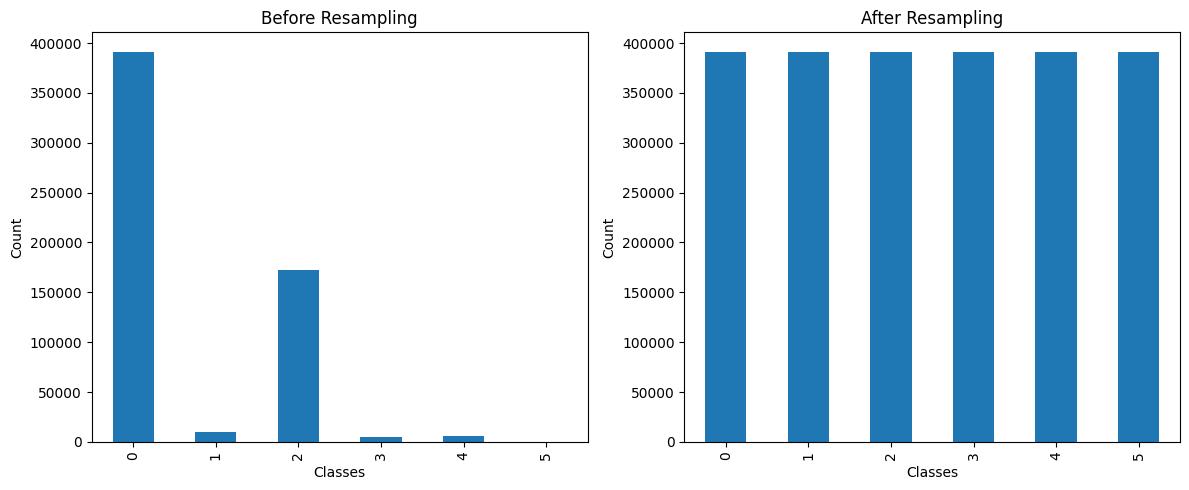

In [ ]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.unique

# ----------------------------
# Assume X, y already defined
# ----------------------------

print("Class distribution before resampling:")
print(Counter(y))

# Count the occurrences of each class in the training data
class_counts = Counter(y)

# Identify classes with only one sample
single_sample_classes = [label for label, count in class_counts.items() if count == 1]

# Determine the target number of samples for oversampling (majority class count)
majority_class_count = max(class_counts.values())

# Define the sampling strategy: oversample all classes with more than one sample up to the majority class count
sampling_strategy = {label: majority_class_count for label, count in class_counts.items() if count > 1}


# Instantiate SMOTE with the defined sampling strategy and a smaller number of neighbors (if needed for other small classes)
# Check if there are any classes left to oversample after excluding single-sample ones
if sampling_strategy:
    # Determine a safe k_neighbors value: the minimum number of samples in the classes to be oversampled, minus 1.
    # If all remaining classes have more than 1 sample, k_neighbors=1 is safe.
    # If there are classes with 2 samples, k_neighbors must be 1.
    min_samples_in_oversampled_classes = min(sampling_strategy.values()) if sampling_strategy else 0
    # k_neighbors should be less than or equal to the number of samples in the smallest class being oversampled
    # Since we are oversampling to the majority class count, min_samples_in_oversampled_classes is the majority count.
    # We need k_neighbors to be based on the original counts of the minority classes being oversampled.
    # Let's find the minimum count among the classes included in the sampling_strategy
    min_original_minority_count = min([count for label, count in class_counts.items() if label in sampling_strategy])
    k_neighbors_value = min(5, max(1, min_original_minority_count - 1)) if min_original_minority_count > 1 else 1


    sm = SMOTE(random_state=42, sampling_strategy=sampling_strategy, k_neighbors=k_neighbors_value)

    X_resampled, y_resampled = sm.fit_resample(X, y)

    print("Class distribution after resampling:")
    print(Counter(y_resampled))
    print(f"Classes with a single sample (excluded from SMOTE): {single_sample_classes}")

    # ----------------------------
    # Plot class distribution
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Before resampling
    pd.Series(y).value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title("Before Resampling")
    axes[0].set_xlabel("Classes")
    axes[0].set_ylabel("Count")

    # After resampling
    pd.Series(y_resampled).value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title("After Resampling")
    axes[1].set_xlabel("Classes")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

else:
    print("No classes to oversample after excluding single-sample classes.")
    X_resampled = X
    y_resampled = y

14. Validation split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.1, random_state=42, stratify=y_resampled
)

15. Reducing size of train set for faster results

In [ ]:
sample_size = 0.1

print(f"Original training data size: {X_train.shape[0]}")
print(f"Sampling {sample_size * 100}% of the training data for faster training.")

# Use stratified sampling to maintain class proportions in the smaller sample
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=sample_size, random_state=42, stratify=y_train
)

Original training data size: 2112669
Sampling 10.0% of the training data for faster training.


In [ ]:
X_train_small.shape, X_test.shape, y_train_small.shape, y_test.shape

((211266, 77), (234741, 77), (211266,), (234741,))

16. Training & Evaluation

▶ Training Logistic Regression
Training Time: 289.93s | Testing Time: 0.26s
Train Accuracy: 0.9196 | Test Accuracy: 0.9211
▶ Training Random Forest
Training Time: 128.25s | Testing Time: 5.57s
Train Accuracy: 1.0000 | Test Accuracy: 0.9986
▶ Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:43:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Time: 33.58s | Testing Time: 3.94s
Train Accuracy: 0.9995 | Test Accuracy: 0.9990

Summary of Model Performance

--- Logistic Regression ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.87      0.84     39123
           1       0.96      0.96      0.96     39123
           2       0.92      0.89      0.91     39124
           3       0.91      0.92      0.91     39124
           4       0.92      0.89      0.91     39124
           5       1.00      1.00      1.00     39123

    accuracy                           0.92    234741
   macro avg       0.92      0.92      0.92    234741
weighted avg       0.92      0.92      0.92    234741



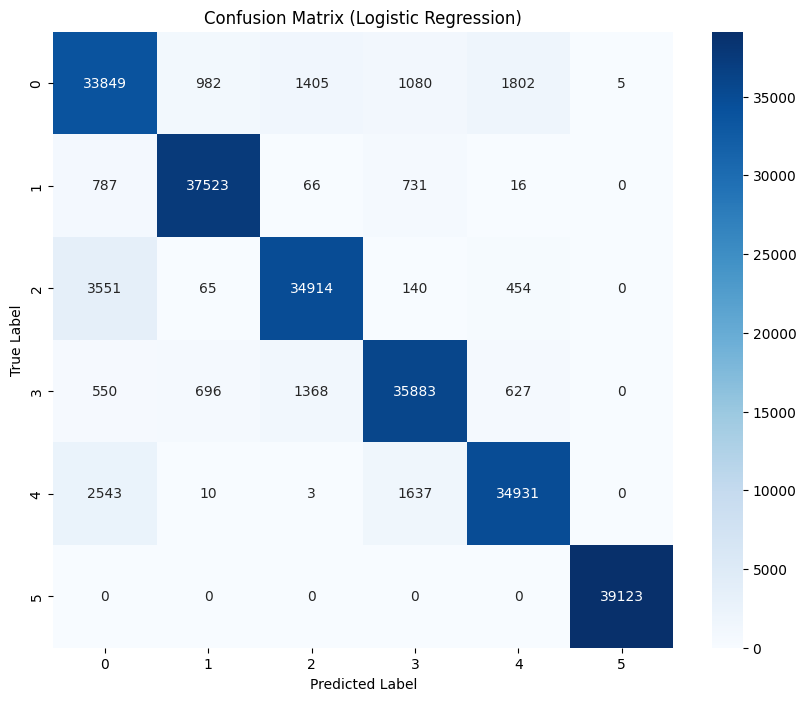


--- Random Forest ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39123
           1       1.00      1.00      1.00     39123
           2       1.00      1.00      1.00     39124
           3       1.00      1.00      1.00     39124
           4       1.00      1.00      1.00     39124
           5       1.00      1.00      1.00     39123

    accuracy                           1.00    234741
   macro avg       1.00      1.00      1.00    234741
weighted avg       1.00      1.00      1.00    234741



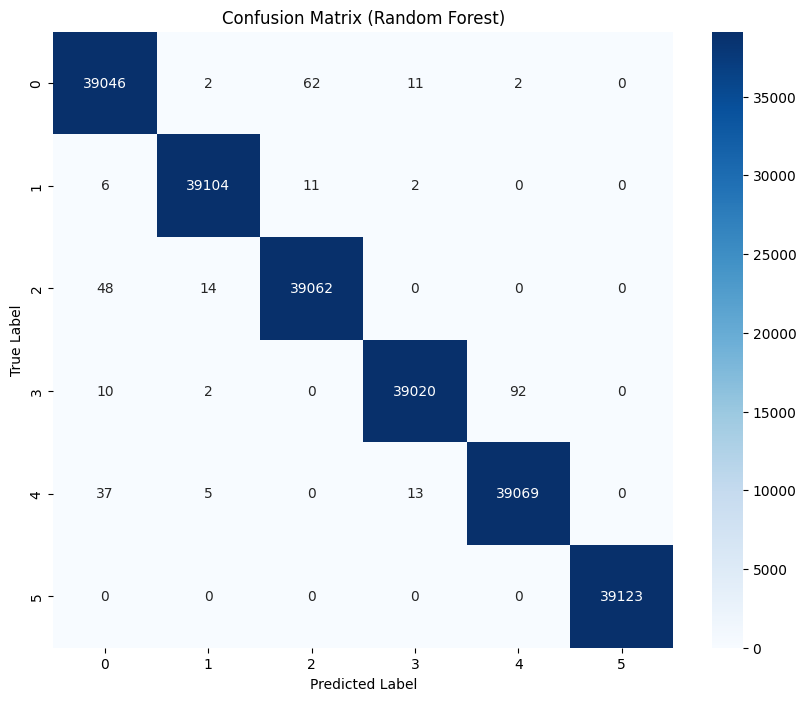


--- XGBoost ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39123
           1       1.00      1.00      1.00     39123
           2       1.00      1.00      1.00     39124
           3       1.00      1.00      1.00     39124
           4       1.00      1.00      1.00     39124
           5       1.00      1.00      1.00     39123

    accuracy                           1.00    234741
   macro avg       1.00      1.00      1.00    234741
weighted avg       1.00      1.00      1.00    234741



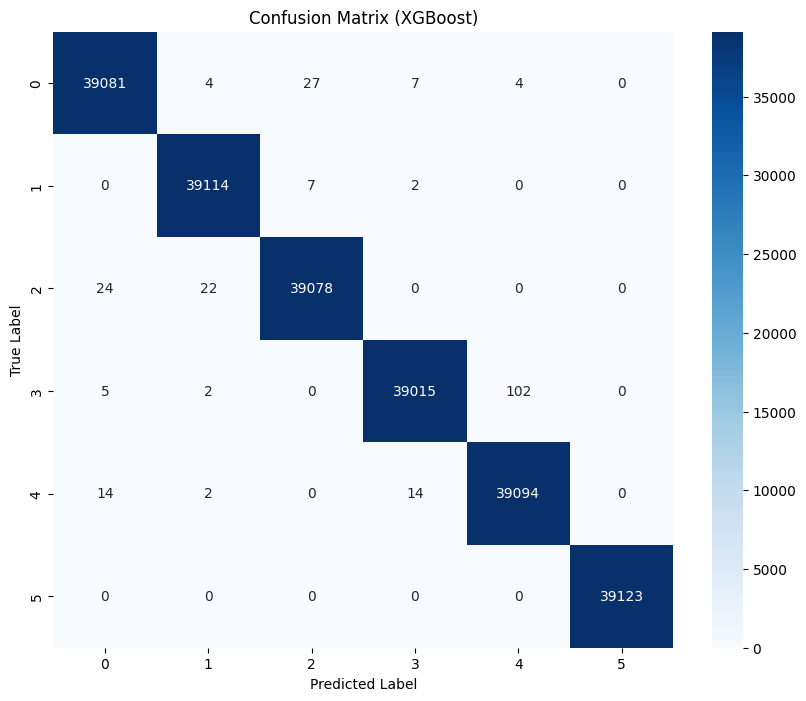

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
}

results = {}

# Train all models
# Use the resampled data for training
# Use the resampled test data for evaluation as well
x_train_used = X_train_small
y_train_used = y_train_small
x_test_used = X_test
y_test_used = y_test


for name, model in models.items():
    print("="*60)
    print(f"▶ Training {name}")

    # Training time
    start = time.time()

    # Map the labels to a contiguous range for XGBoost if needed
    if name == "XGBoost":
        unique_labels = sorted(y_train_used.unique()) # Get unique labels and sort them
        label_map = {label: i for i, label in enumerate(unique_labels)}
        y_train_mapped = y_train_used.map(label_map)
        model.fit(x_train_used, y_train_mapped)
    else:
        model.fit(x_train_used, y_train_used)

    train_time = time.time() - start

    # Training performance
    if name == "XGBoost":
        y_train_pred_mapped = model.predict(x_train_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_train_pred = np.array([reverse_label_map[pred] for pred in y_train_pred_mapped])
    else:
        y_train_pred = model.predict(x_train_used)


    train_acc = accuracy_score(y_train_used, y_train_pred)

    # Testing time
    start = time.time()
    if name == "XGBoost":
        y_test_pred_mapped = model.predict(x_test_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_test_pred = np.array([reverse_label_map[pred] for pred in y_test_pred_mapped])
    else:
        y_test_pred = model.predict(x_test_used)

    test_time = time.time() - start
    test_acc = accuracy_score(y_test_used, y_test_pred)

    # Store results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Training Time": train_time,
        "Testing Time": test_time,
        "Confusion Matrix": confusion_matrix(y_test_used, y_test_pred),
        "Classification Report": classification_report(y_test_used, y_test_pred)
    }

    # Print results
    print(f"Training Time: {train_time:.2f}s | Testing Time: {test_time:.2f}s")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

# After training, print classification reports and plot confusion matrices
print("\n" + "="*60)
print("Summary of Model Performance")
print("="*60)

for name, result in results.items():
    print(f"\n--- {name} ---")
    print("\nClassification Report (Test Data):")
    print(result["Classification Report"])

    # Confusion Matrix
    cm = result["Confusion Matrix"]
    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(np.unique(y_test_used)),
                yticklabels=sorted(np.unique(y_test_used)))
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

17. Comparing the models accuracies

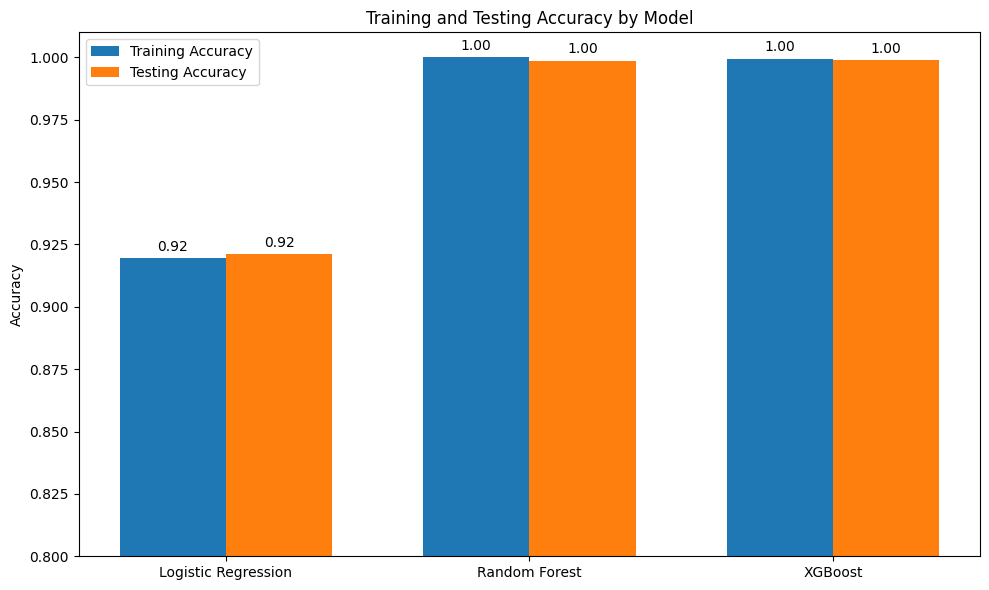

In [ ]:
model_names = list(results.keys())
train_accuracy = [metrics['Train Accuracy'] for metrics in results.values()]
test_accuracy = [metrics['Test Accuracy'] for metrics in results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training and Testing Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization
plt.tight_layout()
plt.show()

18. Testing

In [ ]:
# The true labels are numerical (0-21), printing 'Attack'/'Normal' is misleading
# and likely relies on an unstated mapping (e.g., 0=normal, non-0=attack).
# We will use a more reliable index and print the actual numerical labels.

example_index = 4 # A random index likely to be one of the SMOTE-generated samples
# Access the row using .iloc for positional indexing
example_data = X_test.iloc[[example_index]]
true_label = y_test.iloc[example_index]

print(f"Example index: {example_index}")
print(f"True numerical label: {true_label}")
print("-" * 30)

# Make predictions with each model
for name, model in models.items():
    prediction = model.predict(example_data)[0]

    # Handle XGBoost's mapped prediction
    if name == "XGBoost":
        # y_test_used was not mapped, so we need to map the prediction back
        reverse_label_map = {i: label for label, i in label_map.items()}
        prediction = reverse_label_map.get(prediction, prediction) # Get original label or keep if not found

    print(f"{name} Prediction: {prediction}")

Example index: 4
True numerical label: 2
------------------------------
Logistic Regression Prediction: 2
Random Forest Prediction: 2
XGBoost Prediction: 2
